# Optimización de costos en microrred aislada con generadores diesel
**MILP, UC, scheduling**  

V1: Adaptado a PYOMO desde la implementación original en [https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html](https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html) y en el Ejemplo 12.15 del libro [Model Building in Mathematical Programming](https://share.google/ovWcmGq54LiyOcWm8) de H. Paul Williams (5ª edición, págs. 270-271 y 325-326).

Formulación MILP con:
- Satisfacción exacta de la demanda por período
- Restricción de reserva operativa (15% sobre la demanda)
- Costos fijos por generador activo, costos marginales y costos de arranque
- Objetivo: minimizar costo total de operación

V2: El problema de Williams de despacho nacional (≈ 45 GW) redimensionado a escala de microrred (≈ 2.1 MW pico). Se reeplazaron los generadores térmicos por generadores diesel.

V3: Se pasa de una representación agregada de la demanda en 5 bloques horarios a una discretización horaria completa (24 períodos), lo cual permite capturar con mayor fidelidad las rampas de demanda, especialmente en los períodos de transición (mañana y tarde).

Esta mayor resolución temporal es clave para evaluar correctamente:
- decisiones de encendido/apagado de generadores,
- costos de arranque,
- y utilización de unidades en condiciones de carga parcial.

## Problema: Gestión Energética de Microrred con generadores diesel

Una flota de 27 grupos generadores diesel está disponible para satisfacer la demanda eléctrica de una microrred aislada a lo largo de un día:

|       demand_hourly             |                                    |
| :-------------------------------| :--------------------------------- |
|   820, 790, 810, 800, 830, 870, |  00–05: valle nocturno             |
   1050,1380,1575,1420,1350,1380, |  06–11: rampa matutina y mañana    |
   1520,1480,1400,1620,1850,2050, |  12–17: tarde y rampa vespertina   |
   2100,1980,1750,1550,1350,1100, |  18–23: pico y descenso nocturno   |

Hay tres tipos de generadores diesel disponibles, 12 pequeños (40 KW), 10 medianos (100 KW) y 5 grandes (250 KW). Cada generador opera entre un nivel mínimo (50% de capacidad nominal) y un nivel máximo. Existen costos de O&M (operación y mantenimiento) fijos, costos de combustible (modelados con curva cuadrática linealizada), costos de arranque y de apagado. Cada generador debe permanecer encendido/apagado un tiempo mínimo tras cada transición de estado. Los datos de demanda durante las 24 horas y las características de los generadores se muestran en la sección **Carga de datos**.

La capacidad total instalada es 2.730 kW (12×40 + 10×100 + 5×250). Considerando la reserva del 15%, la demanda máxima factible es ≈ 2.374 kW, por lo que el pico de 2.100 kW tiene margen de seguridad.

In [1]:
import pyomo.environ as pe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

## Carga de Datos

In [2]:
generator_data = pd.read_csv(
    "data/generators_diesel_v3.csv",
    index_col="generator_class",
)
generator_data

,num_available,min_output,max_output,cost_per_hour,startup_cost,shutdown_cost,min_up_time,min_down_time,state0
generator_class,,,,,,,,,
diesel_small,12,20.0,40.0,2.5,5.0,2.5,1,1,12
diesel_med,10,50.0,100.0,5.8,12.0,6.0,1,1,10
diesel_large,5,125.0,250.0,14.5,25.0,12.5,1,1,2


In [3]:
time_period_data = pd.read_csv(
    "data/time_periods_v3.csv",
    parse_dates=["time_period"],
    index_col="time_period",
)
time_period_data

,expected_demand,minimum_active_capacity
time_period,,
2024-01-01 00:00:00,820,943.00
2024-01-01 01:00:00,790,908.50
2024-01-01 02:00:00,810,931.50
2024-01-01 03:00:00,800,920.00
2024-01-01 04:00:00,830,954.50
2024-01-01 05:00:00,870,1000.50
2024-01-01 06:00:00,1050,1207.50
2024-01-01 07:00:00,1380,1587.00
2024-01-01 08:00:00,1575,1811.25


## Conjuntos

In [4]:
GENERATORS   = list(generator_data.index)        # ['diesel_small', 'diesel_med', 'diesel_large']
TIME_PERIODS = list(time_period_data.index)       # lista de timestamps (5 períodos)
T            = list(range(len(TIME_PERIODS)))     # índices enteros 0..4 para Pyomo

print(f"Clases de generadores : {GENERATORS}")
print(f"Número de períodos    : {len(T)}")

Clases de generadores : ['diesel_small', 'diesel_med', 'diesel_large']
Número de períodos    : 24


## Parámetros

Los parámetros del modelo se construyen como diccionarios Python a partir de los DataFrames cargados.

- $n_g$: unidades disponibles de la clase $g$
- $P^{\min}_g$, $P^{\max}_g$: límites de producción por unidad [kW]
- $c_g$: costo fijo de O&M por hora por unidad activa [$/h]
- $s^u_g$: costo de arranque [$]
- $s^d_g$: costo de apagado [$]
- $\tau^{\mathrm{up}}_g$, $\tau^{\mathrm{dn}}_g$: tiempos mínimos de encendido/apagado [períodos]
- $a^0_g$: estado inicial (unidades activas antes del primer período)
- $D_t$: demanda esperada en el período $t$ [kW]
- $\bar{D}_t$: capacidad activa mínima requerida en el período $t$ [kW]
- $S_j^g$, $s_j^g$: pendiente e intercepto del segmento $j$ de la curva de combustible de la clase $g$

In [5]:
# ── Parámetros por clase de generador ───────────────────────────────────────
num_available = generator_data['num_available'].to_dict()
min_output    = generator_data['min_output'].to_dict()
max_output    = generator_data['max_output'].to_dict()
cost_per_hour = generator_data['cost_per_hour'].to_dict()
startup_cost  = generator_data['startup_cost'].to_dict()
shutdown_cost = generator_data['shutdown_cost'].to_dict()
min_up_time   = generator_data['min_up_time'].to_dict()
min_down_time = generator_data['min_down_time'].to_dict()
state0        = generator_data['state0'].to_dict()

# ── Parámetros por período (indexados por entero) ────────────────────────────
expected_demand         = {i: time_period_data['expected_demand'].iloc[i]         for i in T}
minimum_active_capacity = {i: time_period_data['minimum_active_capacity'].iloc[i] for i in T}

## Linealización de la Curva de Costo de Combustible
### Enfoque Parisio (2014)

Dado que los MILP son computacionalmente más eficientes que los MIQP, la función de costo de combustible de un generador diesel:

$$f(P) = a P^2 + b P \quad [\text{\$/h}]$$

se aproxima por el máximo de funciones afines sin introducir variables binarias adicionales:

$$f(P) \approx \sigma = \max_{j=1,\dots,n}\{S_j P + s_j\}$$

donde los coeficientes de cada segmento $j$ se obtienen evaluando la tangente de $f$ en el punto de soporte $P_j$:

$$S_j = f'(P_j) = 2aP_j + b \qquad s_j = f(P_j) - S_j P_j = -aP_j^2$$

Extensión a clases de generadores (formulación agregada): si hay $n_{g,t}$ unidades activas de la clase $g$ produciendo $P^{\mathrm{D}}_{g,t}$ kW en total, el costo de combustible agregado es:

$$n_{g,t} \cdot f\!\left(\frac{P^{\mathrm{D}}_{g,t}}{n_{g,t}}\right) = a\frac{{P^{\mathrm{D}}_{g,t}}^2}{n_{g,t}} + b\, P^{\mathrm{D}}_{g,t}$$

Con la aproximación lineal tangente en cada punto de soporte, esto se convierte en el conjunto de restricciones lineales:

$$\sigma_{g,t} \geq S_j^{g} \cdot P^{\mathrm{D}}_{g,t} + s_j^{g} \cdot n_{g,t} \qquad \forall j = 1, \dots, n_{\mathrm{seg}}$$

Esta formulación es lineal porque $S_j^{g}$ y $s_j^{g}$ son constantes, $P^{\mathrm{D}}_{g,t}$ es continua y $n_{g,t}$ es entera.

Se definen los coeficientes cuadráticos de la función de costo de combustible por unidad:

$$f_g(P) = a_g P^2 + b_g P \quad [\text{\$/h}]$$

y se calculan los segmentos lineales evaluando las tangentes en $n_{\mathrm{seg}} = 3$ puntos de soporte equidistantes entre $P^{\min}_g$ y $P^{\max}_g$.

Los coeficientes (Tabla 2.1 de Nemati) $a$ en $ml/kW^{2}h$ y $b$ en $l/kWh$ se multiplicaron por un precio de combustible estimado de $1.2 $/l$.


In [6]:
# ── Coeficientes de la curva cuadrática de combustible por clase ─────────────
# f(P) = a·P² + b·P  [$/h],  P en kW
# Los valores de 'a' capturan la no linealidad del consumo específico de combustible.
# Los valores de 'b' son consistentes con el costo marginal a carga media.
quad_params = {
    'diesel_small': {'a': 0.003,   'b': 0.18},   # $/(kW²·h), $/(kW·h)
    'diesel_med':   {'a': 0.0012,  'b': 0.20},
    'diesel_large': {'a': 0.0004,  'b': 0.22},
}

N_SEG = 3   # número de puntos de soporte para la linealización

# ── Cálculo de segmentos lineales ─────────────────────────────────────────────
# En cada punto P_j:
#   S_j = f'(P_j) = 2·a·P_j + b      (pendiente)
#   s_j = f(P_j) - S_j·P_j = -a·P_j² (intercepto por unidad)
lin_segments = {}   # {g: {'slopes': [...], 'intercepts': [...]}}

for g in GENERATORS:
    a  = quad_params[g]['a']
    b  = quad_params[g]['b']
    p_min = min_output[g]
    p_max = max_output[g]
    
    support_points = np.linspace(p_min, p_max, N_SEG)
    slopes     = [2 * a * pj + b for pj in support_points]
    intercepts = [-a * pj**2      for pj in support_points]
    lin_segments[g] = {'slopes': slopes, 'intercepts': intercepts, 'support': support_points}

SEGMENTS = list(range(N_SEG))   # índices de segmento: 0, 1, 2

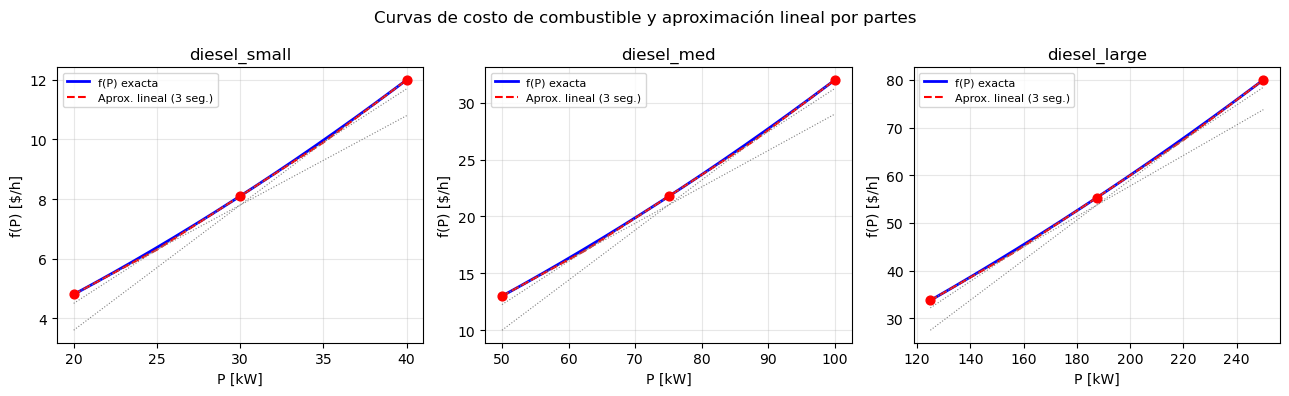

In [7]:
# ── Visualización de las curvas y su aproximación ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Curvas de costo de combustible y aproximación lineal por partes", fontsize=12)

for ax, g in zip(axes, GENERATORS):
    a = quad_params[g]['a']
    b = quad_params[g]['b']
    p_min, p_max = min_output[g], max_output[g]
    
    P = np.linspace(p_min, p_max, 200)
    f_exact = a * P**2 + b * P
    
    # Aproximación por máximo de rectas
    segs = lin_segments[g]
    f_approx = np.max(
        np.array([segs['slopes'][j] * P + segs['intercepts'][j] for j in SEGMENTS]), axis=0
    )
    
    ax.plot(P, f_exact,  'b-',  lw=2,   label='f(P) exacta')
    ax.plot(P, f_approx, 'r--', lw=1.5, label='Aprox. lineal (3 seg.)')
    for j in SEGMENTS:
        Sj = segs['slopes'][j]; sj = segs['intercepts'][j]
        ax.plot(P, Sj * P + sj, 'gray', lw=0.8, ls=':')
    ax.scatter(segs['support'], [a*pj**2 + b*pj for pj in segs['support']],
               color='red', zorder=5, s=40)
    ax.set_xlabel("P [kW]"); ax.set_ylabel("f(P) [$/h]")
    ax.set_title(g); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# ── Tabla resumen de segmentos ────────────────────────────────────────────────
print("\nSegmentos lineales de la curva de combustible:")
print(f"{'Clase':<14} {'Seg':>4} {'P_soporte (kW)':>16} {'Pendiente S_j':>15} {'Intercepto s_j':>16}")
print("-" * 68)
for g in GENERATORS:
    segs = lin_segments[g]
    for j in SEGMENTS:
        print(f"{g:<14} {j:>4} {segs['support'][j]:>16.1f} {segs['slopes'][j]:>15.5f} {segs['intercepts'][j]:>16.4f}")
    print()


Segmentos lineales de la curva de combustible:
Clase           Seg   P_soporte (kW)   Pendiente S_j   Intercepto s_j
--------------------------------------------------------------------
diesel_small      0             20.0         0.30000          -1.2000
diesel_small      1             30.0         0.36000          -2.7000
diesel_small      2             40.0         0.42000          -4.8000

diesel_med        0             50.0         0.32000          -3.0000
diesel_med        1             75.0         0.38000          -6.7500
diesel_med        2            100.0         0.44000         -12.0000

diesel_large      0            125.0         0.32000          -6.2500
diesel_large      1            187.5         0.37000         -14.0625
diesel_large      2            250.0         0.42000         -25.0000



## Construcción del Modelo Pyomo

In [9]:
model = pe.ConcreteModel(name="UC_Microgrid_Diesel")

## Conjuntos del Modelo

In [10]:
model.G = pe.Set(initialize=GENERATORS, doc="Clases de generadores diesel")
model.T = pe.Set(initialize=T, ordered=True, doc="Períodos de tiempo (índices enteros)")
model.J = pe.Set(initialize=SEGMENTS, doc="Segmentos de linealización de costo combustible")

## Parámetros del Modelo

In [11]:
model.num_available           = pe.Param(model.G, initialize=num_available,           doc="Unidades disponibles")
model.min_output              = pe.Param(model.G, initialize=min_output,              doc="Producción mínima [kW]")
model.max_output              = pe.Param(model.G, initialize=max_output,              doc="Producción máxima [kW]")
model.cost_per_hour           = pe.Param(model.G, initialize=cost_per_hour,           doc="Costo fijo O&M [$/h]")
model.startup_cost            = pe.Param(model.G, initialize=startup_cost,            doc="Costo de arranque [$]")
model.shutdown_cost           = pe.Param(model.G, initialize=shutdown_cost,           doc="Costo de apagado [$]")
model.min_up_time             = pe.Param(model.G, initialize=min_up_time,             doc="Tiempo mínimo encendido [períodos]")
model.min_down_time           = pe.Param(model.G, initialize=min_down_time,           doc="Tiempo mínimo apagado [períodos]")
model.state0                  = pe.Param(model.G, initialize=state0,                  doc="Estado inicial")
model.expected_demand         = pe.Param(model.T, initialize=expected_demand,         doc="Demanda esperada [kW]")
model.minimum_active_capacity = pe.Param(model.T, initialize=minimum_active_capacity, doc="Capacidad activa mínima [kW]")

# ── Parámetros de linealización (indexados por clase × segmento) ─────────────
slope_data     = {(g, j): lin_segments[g]['slopes'][j]     for g in GENERATORS for j in SEGMENTS}
intercept_data = {(g, j): lin_segments[g]['intercepts'][j] for g in GENERATORS for j in SEGMENTS}

model.lin_slope     = pe.Param(model.G, model.J, initialize=slope_data,     doc="Pendiente S_j del segmento j de la clase g")
model.lin_intercept = pe.Param(model.G, model.J, initialize=intercept_data, doc="Intercepto s_j del segmento j de la clase g")

## Variables de Decisión
### Variables Continuas

| Variable | Índices | Dominio | Unidad | Descripción |
| :--- | :---: | :---: | :---: | :--- |
| $P^{\mathrm{D}}_{g,t}$ (`output`) | $g \in G,\; t \in T$ | $\mathbb{R}_{\geq 0}$ | kW | Producción total de la clase $g$ en el período $t$ |
| $\sigma_{g,t}$ (`sigma`) | $g \in G,\; t \in T$ | $\mathbb{R}_{\geq 0}$ | $/h | Costo de combustible total de la clase $g$ en $t$ (variable auxiliar de linealización) |

### Variables Enteras

| Variable | Índices | Dominio | Unidad | Descripción |
| :--- | :---: | :---: | :---: | :--- |
| $n_{g,t}$ (`num_active`) | $g \in G,\; t \in T$ | $\{0, 1, \ldots, n_g\}$ | unidades | Número de generadores de la clase $g$ activos en el período $t$ |
| $u_{g,t}$ (`num_startup`) | $g \in G,\; t \in T$ | $\mathbb{Z}_{\geq 0}$ | unidades | Número de generadores de la clase $g$ que **arrancan** en el período $t$ |
| $v_{g,t}$ (`num_shutdown`) | $g \in G,\; t \in T$ | $\mathbb{Z}_{\geq 0}$ | unidades | Número de generadores de la clase $g$ que **se apagan** en el período $t$ |

### Relación entre Variables de Transición de Estado

Las variables enteras satisfacen la identidad de balance:

$$n_{g,t} - n_{g,t-1} = u_{g,t} - v_{g,t} \qquad \forall g,\; t > t_0$$

que se implementa mediante las cotas inferiores separadas para arranques y apagados.

In [12]:
# ── Variable continua: producción total de la clase g en el período t [kW] ──
model.output = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeReals,
    doc="Producción total [kW]"
)

# ── Variable continua: costo de combustible total clase g en período t [$/h] ─
# Variable auxiliar de linealización Parisio: sigma_{g,t} = max_j { S_j·x + s_j·n }
model.sigma = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeReals,
    doc="Costo total de combustible [$/h] — variable de linealización Parisio"
)

# ── Variable entera: generadores activos (cota superior = num_available[g]) ──
def num_active_bounds(m, g, t):
    return (0, m.num_available[g])

model.num_active = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeIntegers,
    bounds=num_active_bounds,
    doc="Número de generadores activos"
)

# ── Variable entera: generadores que arrancan en el período t ─────────────────
model.num_startup = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeIntegers,
    doc="Número de arranques por período"
)

# ── Variable entera: generadores que se apagan en el período t ───────────────
model.num_shutdown = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeIntegers,
    doc="Número de apagados por período"
)

## Restricciones

### 1. Satisfacción de la Demanda

La producción total de todos los generadores en cada período debe igualar la demanda prevista:

$$\sum_{g \in G} P^{\mathrm{D}}_{g,t} = D_t \qquad \forall t \in T$$

In [13]:
def demand_rule(m, t):
    return sum(m.output[g, t] for g in m.G) == m.expected_demand[t]

model.demand_constraint = pe.Constraint(
    model.T, rule=demand_rule,
    doc="Producción total = demanda esperada"
)

### 2. Restricción de Reserva Operativa

Los generadores activos deben tener capacidad suficiente para cubrir un 15% adicional de demanda ajustando la producción de las unidades ya encendidas:

$$\sum_{g \in G} P^{\max}_g \cdot n_{g,t} \geq \bar{D}_t \qquad \forall t \in T$$

In [14]:
def reserve_rule(m, t):
    return sum(m.max_output[g] * m.num_active[g, t] for g in m.G) >= m.minimum_active_capacity[t]

model.reserve_constraint = pe.Constraint(
    model.T, rule=reserve_rule,
    doc="Capacidad activa máxima >= capacidad mínima requerida"
)

### 3. Límites de Producción por Unidad Activa

Cada generador activo opera entre su mínimo técnico y su máximo técnico:

$$P^{\min}_g \cdot n_{g,t} \leq P^{\mathrm{D}}_{g,t} \leq P^{\max}_g \cdot n_{g,t} \qquad \forall g \in G, t \in T$$

In [15]:
def output_lower_rule(m, g, t):
    return m.output[g, t] >= m.min_output[g] * m.num_active[g, t]

model.output_lower = pe.Constraint(
    model.G, model.T, rule=output_lower_rule,
    doc="Producción >= mínimo × generadores activos"
)

def output_upper_rule(m, g, t):
    return m.output[g, t] <= m.max_output[g] * m.num_active[g, t]

model.output_upper = pe.Constraint(
    model.G, model.T, rule=output_upper_rule,
    doc="Producción <= máximo × generadores activos"
)

### 4. Balance de Estado: Arranques

La variable $u_{g,t}$ captura el incremento neto de unidades activas entre períodos.

**Períodos $t > t_0$:**
$$u_{g,t} \geq n_{g,t} - n_{g,t-1} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

**Primer período $t_0$:**
$$u_{g,t_0} \geq n_{g,t_0} - a^0_g \qquad \forall g \in G$$

In [16]:
def startup_rule(m, g, t):
    if t == m.T.first():
        return pe.Constraint.Skip
    t_prev = m.T.prev(t)
    return m.num_startup[g, t] >= m.num_active[g, t] - m.num_active[g, t_prev]

model.startup_constraint = pe.Constraint(
    model.G, model.T, rule=startup_rule,
    doc="Arranques en t >= incremento de activos respecto a t-1"
)

def initial_startup_rule(m, g):
    t0 = m.T.first()
    return m.num_startup[g, t0] >= m.num_active[g, t0] - m.state0[g]

model.initial_startup = pe.Constraint(
    model.G, rule=initial_startup_rule,
    doc="Arranques en t₀ >= activos en t₀ − estado inicial"
)

### 5. Balance de Estado: Apagados

Simétricamente, $v_{g,t}$ captura el decremento neto de unidades activas.

**Períodos $t > t_0$:**
$$v_{g,t} \geq n_{g,t-1} - n_{g,t} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

**Primer período $t_0$:**
$$v_{g,t_0} \geq a^0_g - n_{g,t_0} \qquad \forall g \in G$$

In [17]:
def shutdown_rule(m, g, t):
    if t == m.T.first():
        return pe.Constraint.Skip
    t_prev = m.T.prev(t)
    return m.num_shutdown[g, t] >= m.num_active[g, t_prev] - m.num_active[g, t]

model.shutdown_constraint = pe.Constraint(
    model.G, model.T, rule=shutdown_rule,
    doc="Apagados en t >= decremento de activos respecto a t-1"
)

def initial_shutdown_rule(m, g):
    t0 = m.T.first()
    return m.num_shutdown[g, t0] >= m.state0[g] - m.num_active[g, t0]

model.initial_shutdown = pe.Constraint(
    model.G, rule=initial_shutdown_rule,
    doc="Apagados en t₀ >= estado inicial − activos en t₀"
)

### 6. Tiempo Mínimo de Encendido (Min Up-Time)

Si la clase $g$ arranca $u_{g,k}$ unidades en el período $k$, todas deben permanecer encendidas durante al menos $\tau^{\mathrm{up}}_g$ períodos consecutivos:

$$\sum_{k=t-\tau^{\mathrm{up}}_g+1}^{t} u_{g,k} \leq n_{g,t} \qquad \forall g \in G,\; t \geq \tau^{\mathrm{up}}_g$$

Esto garantiza que las unidades arrancadas en el horizonte $[t-\tau^{\mathrm{up}}+1,\, t]$ estén activas en $t$.

In [18]:
def min_up_time_rule(m, g, t):
    mut = int(pe.value(m.min_up_time[g]))
    if mut <= 1:
        return pe.Constraint.Skip   # trivialmente satisfecho con las restricciones de arranque
    t_list = list(m.T)
    if t < mut - 1:
        return pe.Constraint.Skip
    # Suma de arranques en la ventana [t-mut+1 .. t]
    window = [t_list[k] for k in range(t - mut + 1, t + 1) if k >= 0]
    return sum(m.num_startup[g, tau] for tau in window) <= m.num_active[g, t_list[t]]

model.min_up_time_constraint = pe.Constraint(
    model.G, model.T, rule=min_up_time_rule,
    doc="Tiempo mínimo de encendido: unidades arrancadas deben permanecer activas MUT períodos"
)

### 7. Tiempo Mínimo de Apagado (Min Down-Time)

Simétricamente, las unidades apagadas en el período $k$ deben permanecer apagadas durante al menos $\tau^{\mathrm{dn}}_g$ períodos:

$$\sum_{k=t-\tau^{\mathrm{dn}}_g+1}^{t} v_{g,k} \leq n_g - n_{g,t} \qquad \forall g \in G,\; t \geq \tau^{\mathrm{dn}}_g$$

In [19]:
def min_down_time_rule(m, g, t):
    mdt = int(pe.value(m.min_down_time[g]))
    if mdt <= 1:
        return pe.Constraint.Skip
    t_list = list(m.T)
    if t < mdt - 1:
        return pe.Constraint.Skip
    window = [t_list[k] for k in range(t - mdt + 1, t + 1) if k >= 0]
    return sum(m.num_shutdown[g, tau] for tau in window) <= m.num_available[g] - m.num_active[g, t_list[t]]

model.min_down_time_constraint = pe.Constraint(
    model.G, model.T, rule=min_down_time_rule,
    doc="Tiempo mínimo de apagado: unidades cerradas deben permanecer inactivas MDT períodos"
)

### 8. Linealización de la Curva de Combustible (Enfoque Parisio)

Para cada segmento $j$ de la aproximación lineal, se impone que $\sigma_{g,t}$ sea mayor o igual al costo de combustible calculado con la recta tangente en el punto de soporte $j$:

$$\sigma_{g,t} \geq S_j^g \cdot x_{g,t} + s_j^g \cdot n_{g,t} \qquad \forall g \in G,\; t \in T,\; j \in J$$

Como $\sigma_{g,t}$ aparece con signo positivo en el objetivo (minimización), el solver lo fijará en el máximo de las rectas tangentes, reproduciendo la envolvente convexa de la curva cuadrática.

In [20]:
def fuel_cost_linearization_rule(m, g, t, j):
    return m.sigma[g, t] >= m.lin_slope[g, j] * m.output[g, t] + m.lin_intercept[g, j] * m.num_active[g, t]

model.fuel_cost_linearization = pe.Constraint(
    model.G, model.T, model.J, rule=fuel_cost_linearization_rule,
    doc="Linealización Parisio: sigma >= S_j·x + s_j·n para cada segmento j"
)

## Función Objetivo

Se minimiza el costo total de operación, compuesto por cuatro términos:

$$\min \sum_{g \in G} \sum_{t \in T} \left[
  \underbrace{c_g \cdot n_{g,t}}_{\text{O\&M fijo}}
  + \underbrace{\sigma_{g,t}}_{\text{combustible (Parisio)}}
  + \underbrace{s^u_g \cdot u_{g,t}}_{\text{arranque}}
  + \underbrace{s^d_g \cdot v_{g,t}}_{\text{apagado}}
\right]$$

La variable $\sigma_{g,t}$ reemplaza el término lineal de costo marginal de la formulación original, capturando la curvatura del consumo específico de combustible diesel.

In [21]:
def obj_rule(m):
    return sum(
        # Costo fijo de O&M por generadores activos
        m.cost_per_hour[g]  * m.num_active[g, t]
        # Costo de combustible (aproximación lineal Parisio)
        + m.sigma[g, t]
        # Costo de arranque
        + m.startup_cost[g]  * m.num_startup[g, t]
        # Costo de apagado
        + m.shutdown_cost[g] * m.num_shutdown[g, t]
        for g in m.G
        for t in m.T
    )

model.obj = pe.Objective(rule=obj_rule, sense=pe.minimize,
                          doc="Minimizar costo total de operación")

In [22]:
nG, nT, nJ = len(GENERATORS), len(T), N_SEG

print("=" * 60)
print("  RESUMEN DEL MODELO UC — MICRORRED DIESEL")
print("=" * 60)

print("\n── Conjuntos ────────────────────────────────────────")
print(f"  |G| Clases de generadores          : {nG}")
print(f"  |T| Períodos de tiempo             : {nT}")
print(f"  |J| Segmentos de linealización     : {nJ}")

print("\n── Variables continuas ──────────────────────────────")
print(f"  output  (x_{{g,t}})                  : {nG*nT:>4}  [kW]")
print(f"  sigma   (σ_{{g,t}})                  : {nG*nT:>4}  [$/h]")
print(f"  Subtotal continuas                 : {2*nG*nT:>4}")

print("\n── Variables enteras ────────────────────────────────")
print(f"  num_active   (n_{{g,t}})  ∈ [0, n_g] : {nG*nT:>4}  [unidades]")
print(f"  num_startup  (u_{{g,t}})  ≥ 0        : {nG*nT:>4}  [unidades]")
print(f"  num_shutdown (v_{{g,t}})  ≥ 0        : {nG*nT:>4}  [unidades]")
print(f"  Subtotal enteras                   : {3*nG*nT:>4}")

print(f"\n  TOTAL VARIABLES                    : {5*nG*nT:>4}")

print("\n── Restricciones ────────────────────────────────────")
print(f"  Demanda                            : {nT:>4}")
print(f"  Reserva operativa                  : {nT:>4}")
print(f"  Límites producción (inf + sup)     : {2*nG*nT:>4}")
print(f"  Arranque (t>t0 + inicial)          : {nG*(nT-1)+nG:>4}")
print(f"  Apagado  (t>t0 + inicial)          : {nG*(nT-1)+nG:>4}")
print(f"  Min up time                        : {nG*nT:>4}  (activas si MUT>1)")
print(f"  Min down time                      : {nG*nT:>4}  (activas si MDT>1)")
print(f"  Linealización combustible (|G||T||J|): {nG*nT*nJ:>4}")
print("=" * 60)

  RESUMEN DEL MODELO UC — MICRORRED DIESEL

── Conjuntos ────────────────────────────────────────
  |G| Clases de generadores          : 3
  |T| Períodos de tiempo             : 24
  |J| Segmentos de linealización     : 3

── Variables continuas ──────────────────────────────
  output  (x_{g,t})                  :   72  [kW]
  sigma   (σ_{g,t})                  :   72  [$/h]
  Subtotal continuas                 :  144

── Variables enteras ────────────────────────────────
  num_active   (n_{g,t})  ∈ [0, n_g] :   72  [unidades]
  num_startup  (u_{g,t})  ≥ 0        :   72  [unidades]
  num_shutdown (v_{g,t})  ≥ 0        :   72  [unidades]
  Subtotal enteras                   :  216

  TOTAL VARIABLES                    :  360

── Restricciones ────────────────────────────────────
  Demanda                            :   24
  Reserva operativa                  :   24
  Límites producción (inf + sup)     :  144
  Arranque (t>t0 + inicial)          :   72
  Apagado  (t>t0 + inicial)        

## Resolución del Modelo

Configuración del solver MILP. Ver [parámetros de GUROBI](https://docs.gurobi.com/projects/optimizer/en/current/concepts/parameters.html).

In [23]:
solver = pe.SolverFactory('gurobi_direct')
solver.options['MIPGap']    = 0      # 0% gap → óptimo garantizado
solver.options['MIPFocus']  = 1      # priorizar encontrar soluciones factibles
solver.options['OutputFlag']= 1      # mostrar log de Gurobi

t0 = time.time()
results = solver.solve(model, tee=True)
cpu_time = time.time() - t0

print(f"\nTiempo de CPU: {cpu_time:.2f} s")

Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0
Set parameter MIPFocus to value 1
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7430U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
MIPGap  0
MIPFocus  1

Academic license 2723234 - for non-commercial use only - registered to nz___@frsf.utn.edu.ar
Optimize a model with 552 rows, 360 columns and 1506 nonzeros (Min)
Model fingerprint: 0x80bd97f6
Model has 288 linear objective coefficients
Variable types: 144 continuous, 216 integer (0 binary)
Coefficient statistics:
  Matrix range     [3e-01, 3e+02]
  Objective range  [1e+00, 3e+01]
  Bounds range     [5e+00, 1e+01]
  RHS range        [2e+00, 2e+03]
Found heuristic solution: objective 14591.712500
Presolve removed 4 rows and 4 columns
Presolve time: 0.01s
Presolved: 

## Verificación de la Solución

In [24]:
tc = results.solver.termination_condition

if tc == pe.TerminationCondition.optimal:
    print("Solución ÓPTIMA encontrada")
elif tc == pe.TerminationCondition.feasible:
    print("Solución FACTIBLE encontrada (límite de tiempo alcanzado)")
elif tc == pe.TerminationCondition.infeasible:
    print("Problema INFACTIBLE")
else:
    print(f"Estado del solver: {tc}")

costo_total = pe.value(model.obj)
print(f"\nCosto total óptimo : ${costo_total:,.2f}")
print(f"Tiempo de CPU      : {cpu_time:.2f} s")

Solución ÓPTIMA encontrada

Costo total óptimo : $12,131.15
Tiempo de CPU      : 0.22 s


## Extracción de Resultados

In [25]:
# ── Descomposición de costos por generador y período ─────────────────────────
rows = []
for g in GENERATORS:
    for i, t in enumerate(TIME_PERIODS):
        na  = int(round(pe.value(model.num_active[g, i])))
        ns  = int(round(pe.value(model.num_startup[g, i])))
        nd  = int(round(pe.value(model.num_shutdown[g, i])))
        out = pe.value(model.output[g, i])
        sig = pe.value(model.sigma[g, i])
        
        c_fixed    = generator_data.loc[g, 'cost_per_hour'] * na
        c_fuel     = sig
        c_startup  = generator_data.loc[g, 'startup_cost']  * ns
        c_shutdown = generator_data.loc[g, 'shutdown_cost'] * nd
        c_total    = c_fixed + c_fuel + c_startup + c_shutdown
        
        rows.append({
            'generator_class': g,
            'time_period':     t,
            'output (kW)':     round(out, 1),
            'num_active':      na,
            'num_startup':     ns,
            'num_shutdown':    nd,
            'sigma ($/h)':     round(sig, 2),
            'cost_fixed ($)':  round(c_fixed, 2),
            'cost_fuel ($)':   round(c_fuel, 2),
            'cost_startup ($)': round(c_startup, 2),
            'cost_shutdown ($)': round(c_shutdown, 2),
            'cost_total ($)':  round(c_total, 2),
        })

solution = pd.DataFrame(rows).set_index(['generator_class', 'time_period'])

## Resumen por periodo

In [26]:
active_capacity = {
    t: sum(
        int(round(pe.value(model.num_active[g, i]))) * generator_data.loc[g, 'max_output']
        for g in GENERATORS
    )
    for i, t in enumerate(TIME_PERIODS)
}

results_summary = pd.DataFrame({
    'Demanda (kW)':             time_period_data['expected_demand'],
    'Cap. Min. Activa (kW)':    time_period_data['minimum_active_capacity'],
    'Cap. Activa Real (kW)':    pd.Series(active_capacity),
})
print(results_summary)

                     Demanda (kW)  Cap. Min. Activa (kW)  \
2024-01-01 00:00:00           820                 943.00   
2024-01-01 01:00:00           790                 908.50   
2024-01-01 02:00:00           810                 931.50   
2024-01-01 03:00:00           800                 920.00   
2024-01-01 04:00:00           830                 954.50   
2024-01-01 05:00:00           870                1000.50   
2024-01-01 06:00:00          1050                1207.50   
2024-01-01 07:00:00          1380                1587.00   
2024-01-01 08:00:00          1575                1811.25   
2024-01-01 09:00:00          1420                1633.00   
2024-01-01 10:00:00          1350                1552.50   
2024-01-01 11:00:00          1380                1587.00   
2024-01-01 12:00:00          1520                1748.00   
2024-01-01 13:00:00          1480                1702.00   
2024-01-01 14:00:00          1400                1610.00   
2024-01-01 15:00:00          1620       

## Tabla de resultados detallada

In [27]:
sep = "=" * 109
print(sep)
print(f"{'Generador':<14} {'Período':<10} {'Act':>5} {'Arr':>5} {'Apr':>5} "
      f"{'Prod.(kW)':>10} {'σ(/h)':>8} {'C.Fixed':>8} {'C.Fuel':>8} {'C.Start':>8} {'C.Stop':>8} {'C.Total':>9}")
print(sep)

for g in GENERATORS:
    for i, t in enumerate(TIME_PERIODS):
        na  = int(round(pe.value(model.num_active[g, i])))
        ns  = int(round(pe.value(model.num_startup[g, i])))
        nd  = int(round(pe.value(model.num_shutdown[g, i])))
        out = pe.value(model.output[g, i])
        sig = pe.value(model.sigma[g, i])
        cf  = generator_data.loc[g, 'cost_per_hour']  * na
        cs  = generator_data.loc[g, 'startup_cost']   * ns
        cd  = generator_data.loc[g, 'shutdown_cost']  * nd
        ct  = cf + sig + cs + cd
        print(f"{g:<14} {str(t.time()):<10} {na:>5d} {ns:>5d} {nd:>5d} "
              f"{out:>10.1f} {sig:>8.2f} {cf:>8.2f} {sig:>8.2f} {cs:>8.2f} {cd:>8.2f} {ct:>9.2f}")
    print("-" * 109)

Generador      Período      Act   Arr   Apr  Prod.(kW)    σ(/h)  C.Fixed   C.Fuel  C.Start   C.Stop   C.Total
diesel_small   00:00:00      12     0     0      300.0    75.60    30.00    75.60     0.00     0.00    105.60
diesel_small   01:00:00      12     0     0      290.0    72.60    30.00    72.60     0.00     0.00    102.60
diesel_small   02:00:00      12     0     0      300.0    75.60    30.00    75.60     0.00     0.00    105.60
diesel_small   03:00:00      12     0     0      300.0    75.60    30.00    75.60     0.00     0.00    105.60
diesel_small   04:00:00      12     0     0      300.0    75.60    30.00    75.60     0.00     0.00    105.60
diesel_small   05:00:00      12     0     0      300.0    75.60    30.00    75.60     0.00     0.00    105.60
diesel_small   06:00:00      12     0     0      420.0   118.80    30.00   118.80     0.00     0.00    148.80
diesel_small   07:00:00      12     0     0      420.0   118.80    30.00   118.80     0.00     0.00    148.80
diesel_sma

## Costo total óptimo

In [28]:
# Descomposición del costo total
c_om_total = sum(
    generator_data.loc[g, 'cost_per_hour'] * int(round(pe.value(model.num_active[g, i])))
    for g in GENERATORS for i in T
)
c_fuel_total = sum(pe.value(model.sigma[g, i]) for g in GENERATORS for i in T)
c_start_total = sum(
    generator_data.loc[g, 'startup_cost'] * int(round(pe.value(model.num_startup[g, i])))
    for g in GENERATORS for i in T
)
c_stop_total = sum(
    generator_data.loc[g, 'shutdown_cost'] * int(round(pe.value(model.num_shutdown[g, i])))
    for g in GENERATORS for i in T
)

print(f"\n Descomposición del costo:")
print(f"   O&M fijo    : {c_om_total:>8.2f}  ({100*c_om_total/costo_total:.1f}%)")
print(f"   Combustible : {c_fuel_total:>8.2f}  ({100*c_fuel_total/costo_total:.1f}%)")
print(f"   Arranque    : {c_start_total:>8.2f}  ({100*c_start_total/costo_total:.1f}%)")
print(f"   Apagado     : {c_stop_total:>8.2f}  ({100*c_stop_total/costo_total:.1f}%)")


 Descomposición del costo:
   O&M fijo    :  2779.00  (22.9%)
   Combustible :  9202.15  (75.9%)
   Arranque    :   100.00  (0.8%)
   Apagado     :    50.00  (0.4%)


## Análisis Gráfico

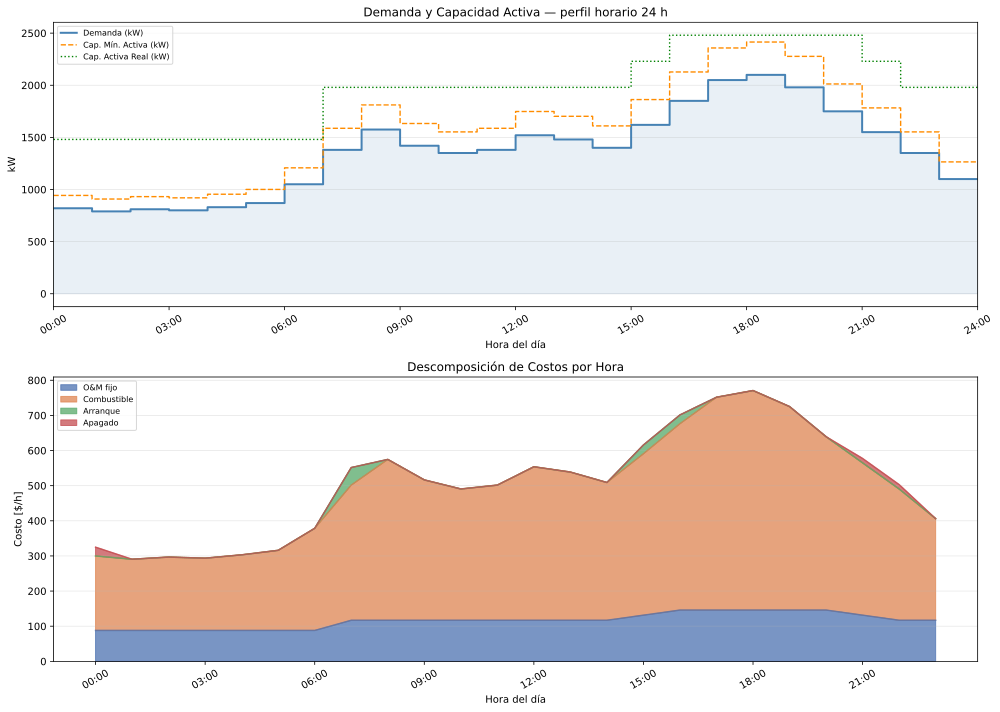

In [29]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']
sns.set_palette(sns.color_palette("deep"))

# Con 24 períodos horarios el "escalón" de cada período dura exactamente 1 hora,
# así que alcanza con usar la hora como coordenada X directamente.
hours       = list(range(24))
demand_vals = list(time_period_data['expected_demand'])
min_cap_vals= list(time_period_data['minimum_active_capacity'])
act_cap_vals= list(results_summary['Cap. Activa Real (kW)'])

# Construir señal de escalones: cada valor se extiende desde h hasta h+1
def make_step(values):
    xs, ys = [], []
    for h, v in enumerate(values):
        xs += [h, h + 1]
        ys += [v, v]
    return xs, ys

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Gráfico 1: Demanda vs capacidad activa ────────────────────────────────────
ax1 = axes[0]
xs_d,  ys_d  = make_step(demand_vals)
xs_mc, ys_mc = make_step(min_cap_vals)
xs_ac, ys_ac = make_step(act_cap_vals)

ax1.fill_between(xs_d, ys_d, alpha=0.12, color='steelblue', step=None)
ax1.plot(xs_d,  ys_d,  color='steelblue',  lw=2,         label='Demanda (kW)')
ax1.plot(xs_mc, ys_mc, color='darkorange',  lw=1.4, ls='--', label='Cap. Mín. Activa (kW)')
ax1.plot(xs_ac, ys_ac, color='green',       lw=1.4, ls=':',  label='Cap. Activa Real (kW)')

ax1.set_xlabel("Hora del día")
ax1.set_ylabel("kW")
ax1.set_title("Demanda y Capacidad Activa — perfil horario 24 h")
ax1.set_xlim(0, 24)
ax1.set_xticks(range(0, 25, 3))
ax1.set_xticklabels([f'{h:02d}:00' for h in range(0, 25, 3)], rotation=30)
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(alpha=0.3, axis='y')

# ── Gráfico 2: Descomposición de costos por hora ──────────────────────────────
ax2 = axes[1]
period_costs = pd.DataFrame(index=hours)
for component, label in [
    ('cost_fixed ($)',    'O&M fijo'),
    ('cost_fuel ($)',     'Combustible'),
    ('cost_startup ($)',  'Arranque'),
    ('cost_shutdown ($)', 'Apagado'),
]:
    period_costs[label] = solution.groupby('time_period')[component].sum().values

period_costs.plot.area(ax=ax2, alpha=0.75)
ax2.set_xlabel("Hora del día"); ax2.set_ylabel("Costo [$/h]")
ax2.set_title("Descomposición de Costos por Hora")
ax2.set_xticks(range(0, 24, 3))
ax2.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], rotation=30)
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [30]:
active_matrix = pd.DataFrame(
    index=GENERATORS, columns=[t.strftime('%H:%M') for t in TIME_PERIODS],
    data=[[int(round(pe.value(model.num_active[g,i]))) for i in T] for g in GENERATORS])
output_matrix = pd.DataFrame(
    index=GENERATORS, columns=[t.strftime('%H:%M') for t in TIME_PERIODS],
    data=[[round(pe.value(model.output[g,i]),1) for i in T] for g in GENERATORS])

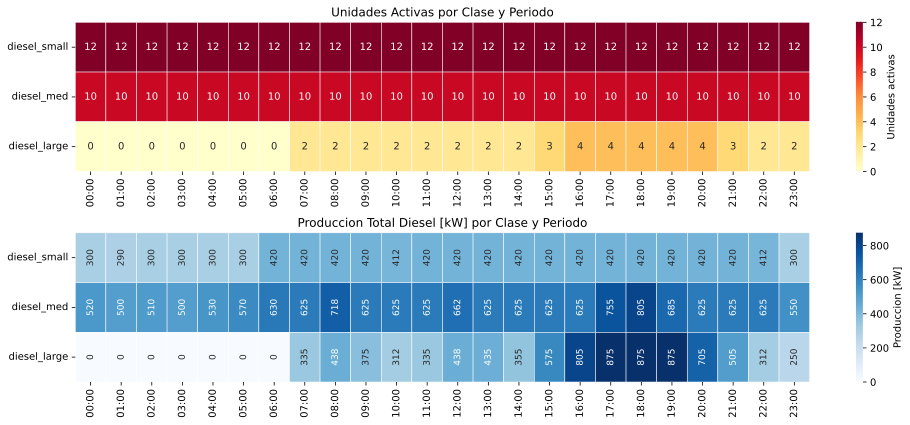

In [31]:
fig, axes = plt.subplots(2,1,figsize=(14,6))
sns.heatmap(active_matrix, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label':'Unidades activas'}, ax=axes[0])
axes[0].set_title('Unidades Activas por Clase y Periodo')
sns.heatmap(output_matrix, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label':'Produccion [kW]'},
            annot_kws={'size':9,'rotation':90}, ax=axes[1])
axes[1].set_title('Produccion Total Diesel [kW] por Clase y Periodo')
plt.tight_layout(); plt.show()

### Generación y demanda por hora y curva de duración de carga

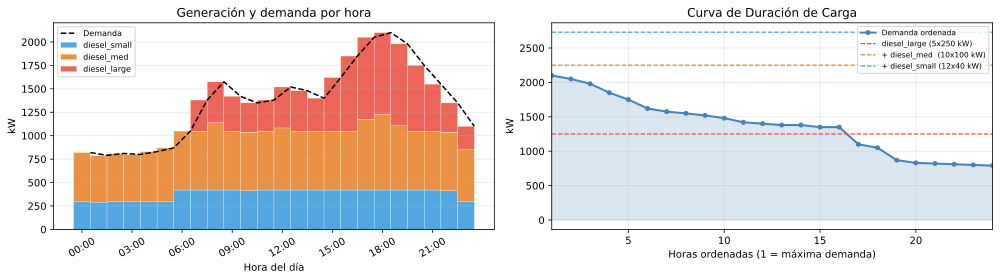

In [32]:
gen_colors = {'diesel_small': '#3498db', 'diesel_med': '#e67e22', 'diesel_large': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax1 = axes[0]
bottoms = np.zeros(24)
for g in GENERATORS:
    vals = [pe.value(model.output[g, i]) for i in T]
    ax1.bar(hours, vals, bottom=bottoms, color=gen_colors[g],
            alpha=0.85, label=g, width=1.0, edgecolor='white', linewidth=0.3)
    bottoms += np.array(vals)

# Superponer curva de demanda
ax1.plot([h + 0.5 for h in hours], demand_vals, 'k--', lw=1.5, label='Demanda', zorder=5)
ax1.set_xlabel("Hora del día"); ax1.set_ylabel("kW")
ax1.set_title("Generación y demanda por hora")
ax1.set_xticks(range(0, 24, 3)); ax1.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], rotation=30)
ax1.legend(fontsize=8); ax1.grid(alpha=0.3, axis='y')

# ── Curva de duración de carga (Load Duration Curve) ─────────────────────────
ax2 = axes[1]
sorted_demand = sorted(demand_vals, reverse=True)
ax2.fill_between(range(1, 25), sorted_demand, alpha=0.2, color='steelblue')
ax2.plot(range(1, 25), sorted_demand, 'steelblue', lw=2, marker='o', ms=4, label='Demanda ordenada')

# Líneas de referencia de capacidad instalada por clase
cap_lines = [
    (5 * 250,             'diesel_large (5x250 kW)', '#e74c3c'),
    (5*250 + 10*100,      '+ diesel_med  (10x100 kW)', '#e67e22'),
    (5*250 + 10*100 + 12*40, '+ diesel_small (12x40 kW)', '#3498db'),
]
for cap, lbl, col in cap_lines:
    ax2.axhline(cap, color=col, lw=1.2, ls='--', label=lbl)

ax2.set_xlabel("Horas ordenadas (1 = máxima demanda)"); ax2.set_ylabel("kW")
ax2.set_title("Curva de Duración de Carga")
ax2.set_xlim(1, 24); ax2.legend(fontsize=7.5, loc='upper right'); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

La Curva de Duración de Carga (CDC) es una forma de representar la demanda que no muestra *cuándo* ocurre cada valor, sino *cuántas horas* el sistema necesita abastecer al menos ese nivel de potencia. Se construye tomando las 24 demandas horarias y ordenándolas de mayor a menor:
- Eje X: posición en el ranking (1 = la hora de mayor demanda, 24 = la de menor)
- Eje Y: valor de demanda en kW

Entonces el punto (1, 2100) significa "durante al menos 1 hora al día la demanda es ≥ 2100 kW", y el punto (20, 830) significa "durante al menos 20 horas al día la demanda es ≥ 830 kW". Las líneas de referencia de capacidad te dicen cuánta potencia instalada aportaría cada clase si estuviera toda encendida:
- Roja (1250 kW): solo los 5 `diesel_large`
- Naranja (2250 kW): `diesel_large` + `diesel_med`
- Azul (2730 kW): toda la flota

La interpretación práctica es la siguiente. Mirando dónde la curva de demanda cruza cada línea de referencia podés estimar qué clases de generadores operan como base (siempre encendidos), cuáles cubren carga media y cuáles solo se necesitan en pico:

- Las `diesel_large` solas (1250 kW) no alcanzan nunca → siempre necesitás `diesel_med` también
- La combinación `large` + `med` (2250 kW) cubre la demanda durante la mayoría de las horas, salvo el pico vespertino donde entrás en zona azul y necesitás algunas `diesel_small`

## Visualización de arranques y apagados

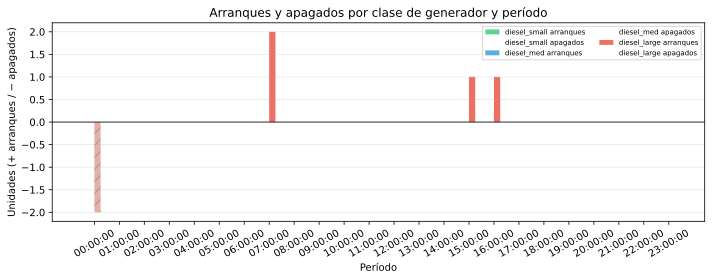

In [33]:
# ── Visualización de arranques y apagados ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
width = 0.25
x = np.arange(len(TIME_PERIODS))
labels = [str(t.time()) for t in TIME_PERIODS]
colors_start = ['#2ecc71', '#3498db', '#e74c3c']
colors_stop  = ['#27ae60', '#2980b9', '#c0392b']

for idx, g in enumerate(GENERATORS):
    starts = [int(round(pe.value(model.num_startup[g, i])))  for i in T]
    stops  = [int(round(pe.value(model.num_shutdown[g, i]))) for i in T]
    offset = (idx - 1) * width
    ax.bar(x + offset - width/2, starts, width, color=colors_start[idx], alpha=0.8, label=f'{g} arranques')
    ax.bar(x + offset - width/2, [-s for s in stops], width, color=colors_stop[idx], alpha=0.4, hatch='//', label=f'{g} apagados')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30)
ax.set_xlabel("Período"); ax.set_ylabel("Unidades (+ arranques / − apagados)")
ax.set_title("Arranques y apagados por clase de generador y período")
ax.legend(fontsize=7, ncol=2, loc='upper right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Estadísticas globales

In [34]:
print(f"   Costo total óptimo   : ${costo_total:,.2f}")
print(f"   Clases generadores   : {len(GENERATORS)}")
print(f"   Períodos             : {len(T)}")
print(f"   Total unidades       : {sum(num_available.values())}")
print(f"   Segmentos lin.       : {N_SEG}")

total_starts = sum(int(round(pe.value(model.num_startup[g, i])))  for g in GENERATORS for i in T)
total_stops  = sum(int(round(pe.value(model.num_shutdown[g, i]))) for g in GENERATORS for i in T)
print(f"   Total arranques      : {total_starts}")
print(f"   Total apagados       : {total_stops}")
print(f"   Costo medio por kWh  : ${costo_total / sum(expected_demand.values()):.4f}/kWh")

   Costo total óptimo   : $12,131.15
   Clases generadores   : 3
   Períodos             : 24
   Total unidades       : 27
   Segmentos lin.       : 3
   Total arranques      : 4
   Total apagados       : 4
   Costo medio por kWh  : $0.3696/kWh


## Análisis Económico

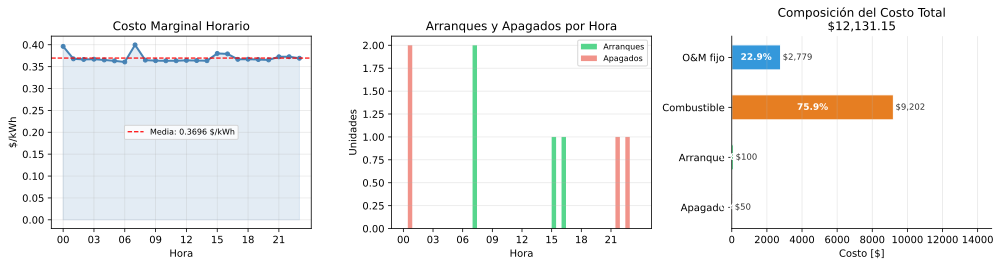

In [35]:
# ── Costo marginal horario ($/kWh) ────────────────────────────────────────────
hourly_cost = period_costs.sum(axis=1).values       # costo total $/h por hora
hourly_cost_per_kwh = hourly_cost / np.array(demand_vals)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

# 1. Costo marginal horario
ax1 = axes[0]
ax1.plot(hours, hourly_cost_per_kwh, 'steelblue', lw=2, marker='o', ms=4)
ax1.fill_between(hours, hourly_cost_per_kwh, alpha=0.15, color='steelblue')
ax1.axhline(costo_total / sum(demand_vals), color='red', lw=1.2, ls='--',
            label=f'Media: {costo_total/sum(demand_vals):.4f} $/kWh')
ax1.set_xlabel("Hora"); ax1.set_ylabel("$/kWh")
ax1.set_title("Costo Marginal Horario")
ax1.set_xticks(range(0, 24, 3)); ax1.set_xticklabels([f'{h:02d}' for h in range(0, 24, 3)])
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# 2. Arranques y apagados acumulados por hora
ax2 = axes[1]
starts_total = [sum(int(round(pe.value(model.num_startup[g, i])))  for g in GENERATORS) for i in T]
stops_total  = [sum(int(round(pe.value(model.num_shutdown[g, i]))) for g in GENERATORS) for i in T]

ax2.bar(hours, starts_total,               color='#2ecc71', alpha=0.8, label='Arranques',  width=0.45, align='edge')
ax2.bar([h + 0.45 for h in hours], stops_total, color='#e74c3c', alpha=0.6, label='Apagados', width=0.45, align='edge')
ax2.set_xlabel("Hora"); ax2.set_ylabel("Unidades")
ax2.set_title("Arranques y Apagados por Hora")
ax2.set_xticks(range(0, 24, 3)); ax2.set_xticklabels([f'{h:02d}' for h in range(0, 24, 3)])
ax2.legend(fontsize=8); ax2.grid(alpha=0.3, axis='y')

# 3. Comparación de componentes de costo (barras apiladas)
ax3 = axes[2]

cost_components = {
    'O&M fijo':    period_costs['O&M fijo'].sum(),
    'Combustible': period_costs['Combustible'].sum(),
    'Arranque':    period_costs['Arranque'].sum(),
    'Apagado':     period_costs['Apagado'].sum(),
}
wedge_colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']

labels  = list(cost_components.keys())
values  = list(cost_components.values())
total   = sum(values)
pcts    = [v / total * 100 for v in values]

bars = ax3.barh(labels, values, color=wedge_colors, edgecolor='white', height=0.5)

# Etiqueta dentro de la barra: porcentaje
for bar, pct, val in zip(bars, pcts, values):
    x_center = bar.get_width() / 2
    ax3.text(x_center, bar.get_y() + bar.get_height() / 2,
             f'{pct:.1f}%', ha='center', va='center',
             fontsize=9, fontweight='bold', color='white')
    # Etiqueta fuera de la barra: valor en $
    ax3.text(bar.get_width() + total * 0.01, bar.get_y() + bar.get_height() / 2,
             f'${val:,.0f}', ha='left', va='center', fontsize=8.5, color='#333333')

ax3.set_xlabel("Costo [$]")
ax3.set_title(f"Composición del Costo Total\n${costo_total:,.2f}")
ax3.set_xlim(0, total * 1.22)   # margen derecho para las etiquetas $
ax3.invert_yaxis()               # mayor arriba
ax3.grid(alpha=0.3, axis='x')
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Estadísticas por clase de generador

In [36]:
print(f"{'Clase':<14} {'Energía (kWh)':>14} {'Horas activo':>13} {'C. Total ($)':>13} {'$/kWh':>8} {'Factor uso':>11}")
print("-" * 76)
for g in GENERATORS:
    energia  = sum(pe.value(model.output[g, i]) for i in T)           # kWh (1 h/período)
    h_activo = sum(int(round(pe.value(model.num_active[g, i]))) for i in T)  # unit·h
    c_tot    = solution.loc[g, 'cost_total ($)'].sum()
    max_cap  = generator_data.loc[g, 'max_output'] * generator_data.loc[g, 'num_available']
    f_uso    = energia / (max_cap * 24)
    print(f"{g:<14} {energia:>14.0f} {h_activo:>13d} {c_tot:>13.2f} {c_tot/energia if energia>0 else 0:>8.4f} {f_uso:>11.3f}")
print("-" * 76)
print(f"{'TOTAL':<14} {sum(demand_vals):>14.0f} {'':>13} {costo_total:>13.2f} {costo_total/sum(demand_vals):>8.4f}")

Clase           Energía (kWh)  Horas activo  C. Total ($)    $/kWh  Factor uso
----------------------------------------------------------------------------
diesel_small             9215           288       3260.40   0.3538       0.800
diesel_med              14810           240       5441.50   0.3674       0.617
diesel_large             8800            46       3429.22   0.3897       0.293
----------------------------------------------------------------------------
TOTAL                   32825                    12131.15   0.3696


## Conclusiones

Este modelo implementa un Unit Commitment + Despacho Económico para una microrred diesel con las siguientes extensiones sobre el ejemplo original de Williams:

1. Redimensionamiento a escala de microrred: la demanda fue escalada de ~45 GW (problema nacional) a ~2,1 MW (pico de microrred), con tres clases de generadores diesel de 40, 100 y 250 kW.

2. Costos de apagado: la variable `num_shutdown` y el parámetro `shutdown_cost` capturan los costos de detención de los grupos diesel (fijados en el 50% del costo de arranque, según Nemati et al.).

3. Tiempos mínimos de encendido/apagado: las restricciones MUT y MDT obligan a las unidades a permanecer en su estado actual por al menos el tiempo indicado tras un cambio, evitando el ciclado excesivo y respetando las recomendaciones de Parisio (2014).

4. Linealización Parisio de la curva de combustible: la variable auxiliar $\sigma_{g,t}$ y las restricciones de segmentos tangentes reemplazan el término cuadrático de consumo de combustible por una aproximación lineal convexa por partes, manteniendo la naturaleza MILP del problema (más eficiente que MIQP).

5. Descomposición de costos: el modelo desglosa el costo total en cuatro componentes (O&M, combustible, arranque, apagado), facilitando el análisis económico de la operación de la microrred.